In [1]:
%load_ext autoreload
%autoreload 2

# Example
## Correlation Matrices

An example showing the use of the ```profile``` module and the ```cor_matrix()``` function. ```profile.cor_matrix``` was developed to help identify key feature for machine learning models under varying conditions. 

The ```cor_matrix()``` uses the Pandas ```DataFrame.corr()``` function but provides additional utility so that users can correlate a specified features (x-values) with specified target variables (y-values) while also providing the ability to correlate subsets of the data based on categorical variables (binary classifications) or ```lambda``` fucntions which filter the dataset passed.

```profile.cor_matrix``` derives correlations for an arbitrary number of $x$ datasets or features with an arbitrary number of $y$ datasets or targets. The feature and target data can be passed as their own DataFrame, or a single DataFrame can be passed and the feature and target are specified as a list containing column names. 

The example here uses GOES-10 electron flux and NASA OMNI data to derive a correlation matrices of OMNI data with electron fluxes under varying geomagnetic conditions including quiet-times, storm-times, storm phase, large values of AE, and small values of Sym-H. These correlations can help to identify key features for machine learning models. The example also shows how to investigate colinearity between variables and lagged correlations from a subset of features initally identified to have high correlations with the target variables. 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


path_dat = f'D:\\data\\goes10_omni_1999_2010.hdf5'

In [3]:
from ml_fw import profile as pro
from ml_fw import data_io as dio

In [4]:
dat = pd.read_hdf(path_dat)
dat.head(1)

,index,dd-mm-yyyy,hh:mm:ss.ms,>0.6 MeV,>2 MeV,>4 Mev,GSE X,GSE Y,GSE Z,Year,...,AU,SYM_D index,SYM_H index,ASY_D index,ASY_H index,PC index,Na_Np Ratio,MagnetosonicMach,storm,storm phase
DateTime,,,,,,,,,,,,,,,,,,,,,
1999-03-21 00:02:30,536256,21-03-1999,00:02:30.000,45321.8,52.0909,NaN,30891.2,26282.9,-11469.6,1999,...,13.0,-4.0,-10.0,22.0,19.0,-0.29,99.9,NaN,-1,-1


In [5]:
# define the target variable to correlate with
cor_col = ['>0.6 MeV']
# define the feature variables
fet_col = ['B', 'Bx_GSEGSM','By_GSM', 'Bz_GSM',
           'Vsw', 'Vx_GSE', 'Vy_GSE', 'Vz_GSE', 
           'Tp', 'dynP', 'Esw', 'Beta', 'AlfvenMach', 
           'AE', 'AL', 'AU', 'SYM_D index', 'SYM_H index',
           'ASY_D index', 'ASY_H index', 'PC index', 
           'storm','storm phase']

# identify the categorical columns
# correlations will be computed for a subset of the data
# where the column == 1 and column != 1
cat_dat = ['storm']

# define a number of lambda functions which will be used
# to filter the dataframe. 
# Correlations will be returned where these lambdas are True
mp = lambda x: x['storm phase'] == 1 # correlation when storm phase column = 1, the main phase
rc = lambda x: x['storm phase'] == 2 # equals 2, the recovry phase
storm = lambda x: x['storm'] == 1 # storm times
quiet = lambda x: x['storm'] < 1 # quiet times
sym = lambda x: x['SYM_H index'] < -25 # when Sym-H is less then -25
ae = lambda x: x['AE'] > 500 # when AE is large

# create a dictionary of the lamda functions
# keys are the names of the returned correlations
# values are the evaluated lambda functions
cat = {'quiet':quiet, 'storm':storm,'main phase':mp, 'recovery':rc, 'Sym-H < -25':sym, 'AE > 500':ae}

cor_mat = pro.cor_matrix(f_dat=fet_col, 
                    y_dat=cor_col,
                    cor_dat=dat, cat_dat=cat, numeric_only=True)

c:\Users\murph\miniconda3\envs\mlfw\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\murph\miniconda3\envs\mlfw\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


**NOTE**, in the above example the warning comes because mainphase and recovery phase
are a subset of storm and have the same values which causes the division error.

In [6]:
cor_mat

,All,quiet,storm,main phase,recovery,Sym-H < -25,AE > 500
B,-0.281401,-0.285794,-0.332823,-0.261785,-0.366361,-0.316998,-0.332923
Bx_GSEGSM,-0.000031,-0.007424,-0.011957,-0.048399,-0.004913,0.009252,-0.031338
By_GSM,-0.005211,-0.000410,0.016913,0.006393,0.043446,-0.011481,-0.034265
Bz_GSM,-0.030055,-0.039072,-0.016714,0.058400,-0.077824,0.040697,0.156315
Vsw,0.269982,0.167144,0.260470,0.211247,0.209636,0.254268,0.306836
Vx_GSE,-0.271617,-0.168811,-0.262194,-0.213698,-0.210695,-0.255956,-0.309184
Vy_GSE,-0.107277,-0.111446,-0.113539,-0.110766,-0.144086,-0.095926,-0.089880
Vz_GSE,0.017356,0.021203,0.008001,0.043481,-0.013146,-0.003497,0.040163
Tp,0.067366,0.024421,0.031500,-0.008723,0.005540,0.058868,0.055955
dynP,-0.182955,-0.209588,-0.216092,-0.173920,-0.234884,-0.192506,-0.209966


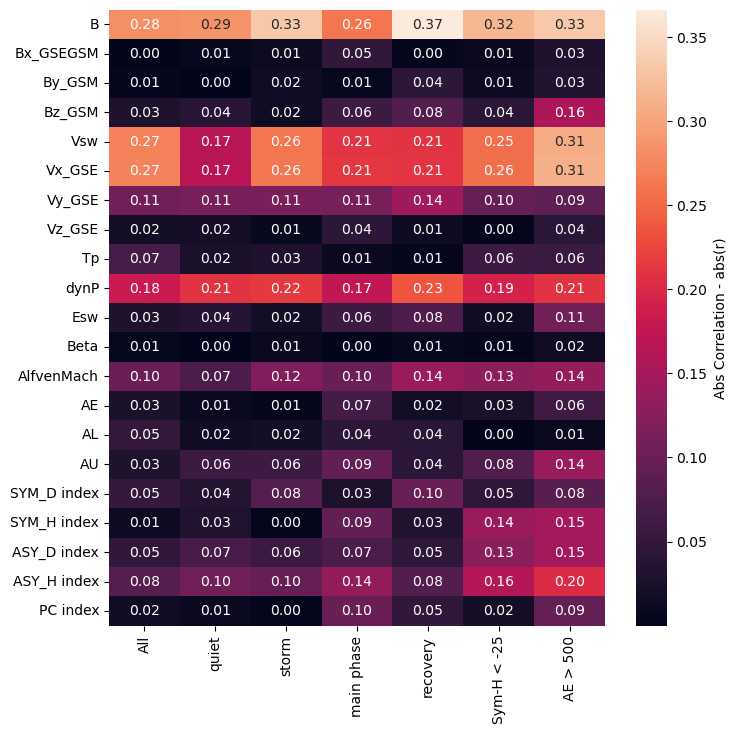

In [7]:
# plot the correlation matrix
plt.figure(figsize=(8, 8))
sns.heatmap(cor_mat[:-2].abs(),annot=True, fmt='.2f', cbar_kws={'label':'Abs Correlation - abs(r)'})
plt.yticks() 
plt.show()

## Lagged Correlation Matrices

Lagged correlation matrices help account for potential time shifts between feature and target variables. If we are investingating a large or dynamic system, then this time shift may account for the response of the system to new internal or external conditions or drivers. In magnetosphere dynamics these timeshift may account for the time for the system to respond to changes in the solar wind. 

Building on the example above, we select OMNI variables (features) which correlate well with GOES electron fluxes (target) and investigate how the correlation changes as we shift the OMNI variables. 

The lagged correlation works by using the ```feat_shift``` function (from the ```data_io``` submodule) which shifts features foward in time for a defined set of periods. The forward shift indicates that features are observed before the response in the target variable. The ```feat_shift``` function shifts features by an arbitraty number of positve (features observed before target response) or negative (features observed after target response... may be mixing features and target in this case) shifts and adds them to provided DataFrame. The ```cor_matrix``` funcion can then be used to calculate the correlation matrix of the returned DataFrame (which then needs to be manipulated a bit for plotting).

Here we'll use the B, Vsw and dynP OMNI variables as features and shift them a number periods ranging from 5 minutes to 5 days. **Note**, that the with a large number of features and lags the correlations can take some time. 



In [8]:
# feat DataFrame
f_df = dat[['B','Vsw','dynP']].copy()
y_df = dat[cor_col].copy()

# generate an array of shifts
# the units of the array are constant
# here we'll use minutes
unit = 'min'
ts1 = np.arange(5,60,5) # 5 minutes shifts to an hour
ts2 = np.arange(60,25*60*5,60) # hourly shifts to 5 days 

# combine the shift arrays
tshift = np.concatenate([ts1,ts2]).tolist()


In [9]:
# derive the time-shift DataFrame
f_dfs = dio.feat_shift(f_df,t_col='index',periods=tshift, unit=unit, drop_na=False) 
f_cols = list(f_df.columns)
f_dfs.head(10)

,B,Vsw,dynP,B 5 min,Vsw 5 min,dynP 5 min,B 10 min,Vsw 10 min,dynP 10 min,B 15 min,...,dynP 7260 min,B 7320 min,Vsw 7320 min,dynP 7320 min,B 7380 min,Vsw 7380 min,dynP 7380 min,B 7440 min,Vsw 7440 min,dynP 7440 min
DateTime,,,,,,,,,,,,,,,,,,,,,
1999-03-21 00:02:30,7.09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1999-03-21 00:07:30,7.06,NaN,NaN,7.09,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1999-03-21 00:12:30,6.86,NaN,NaN,7.06,NaN,NaN,7.09,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1999-03-21 00:17:30,6.91,NaN,NaN,6.86,NaN,NaN,7.06,NaN,NaN,7.09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1999-03-21 00:22:30,6.98,313.4,1.54,6.91,NaN,NaN,6.86,NaN,NaN,7.06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1999-03-21 00:27:30,6.90,NaN,NaN,6.98,313.4,1.54,6.91,NaN,NaN,6.86,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1999-03-21 00:32:30,6.97,NaN,NaN,6.90,NaN,NaN,6.98,313.4,1.54,6.91,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1999-03-21 00:37:30,6.91,NaN,NaN,6.97,NaN,NaN,6.90,NaN,NaN,6.98,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1999-03-21 00:42:30,6.78,NaN,NaN,6.91,NaN,NaN,6.97,NaN,NaN,6.90,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# calculate the correlation matrix
cor_mat = pro.cor_matrix(f_dat=f_dfs.interpolate(), 
                    y_dat=y_df,
                    numeric_only=True)

In [11]:
# rearange the correlation matrix for plotting
cor_sh = pd.DataFrame()
for f in f_cols:
    fc = [col for col in list(cor_mat.index) if f in col]
    cor_sh = pd.concat([cor_sh, cor_mat.loc[fc].reset_index(drop=True).add_suffix(f' {f}').transpose()])

# get a time array for plotting
t_axis = [str(pd.Timedelta(td, unit=unit)) for td in np.concatenate([[0],tshift])]

#cor_sh = cor_sh.set_axis(t_axis,axis=1)
cor_sh = cor_sh.rename(dict(zip(list(cor_sh.columns),t_axis)), axis='columns')


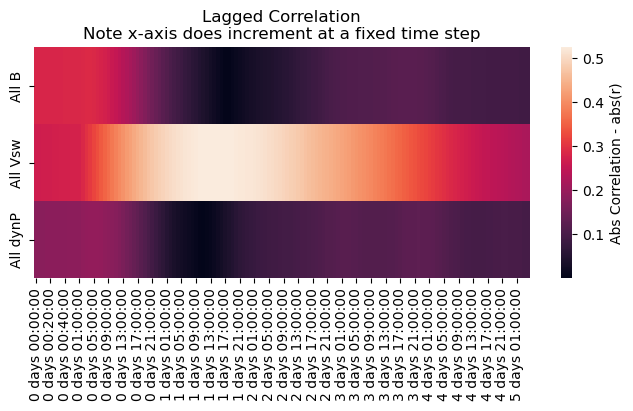

In [12]:
# plot the correlation matrix
plt.figure(figsize=(8, 3))
ax = sns.heatmap(cor_sh.abs(), cbar_kws={'label':'Abs Correlation - abs(r)'})
ax.set_title('Lagged Correlation\nNote x-axis does increment at a fixed time step')
plt.yticks() 
plt.show()

<Axes: title={'center': 'Lagged Correlation\nPositive shifts Features forward in time\n(Features observed before Target)'}, xlabel='Time Shift - hours'>

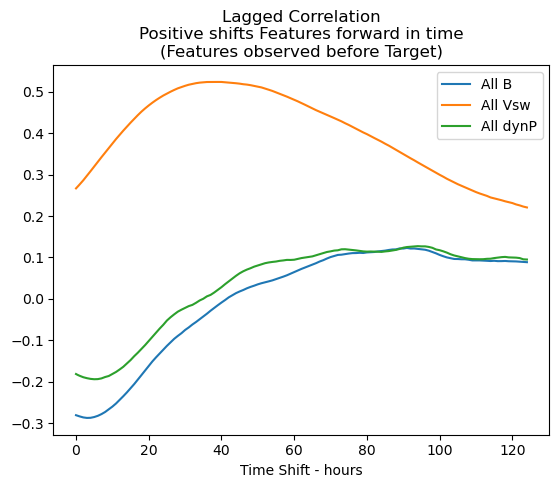

In [13]:
cor_p = cor_sh.transpose()
cor_p['t'] = np.concatenate([[0],tshift])/60
cor_p.plot(x='t',xlabel='Time Shift - hours', title='Lagged Correlation\nPositive shifts Features forward in time\n(Features observed before Target)')